# 02 — Features + label

**Goal.** Take the raw CSV, transform it into something a regression model
can learn from: a clean numeric matrix `X` plus a target column `y_logret`.

**Why this is a separate notebook.** Feature engineering takes a few seconds.
Model training takes a few minutes. Splitting them means you can iterate on
features without rebuilding the model, and vice versa. The final cell here
exposes three things downstream notebooks need:
- `df` — the labeled, cleaned frame
- `FEATS` — list of column names to feed the model
- `H` — the prediction horizon (days ahead)

**Prediction task.** *"Given everything we know on day T, what will the
price be on day T+H?"*  Specifically, predict the **log-return** from T to
T+H. We convert log-return back to a dollar price with
`predicted_price = close[T] * exp(prediction)`.


In [1]:
%run 00_setup.ipynb

loaders ready: load_dataset drop_indicator_warmup add_derived_features label_regression label_classification feature_columns


## 2.1 — Load + warmup cut

`load_dataset()` reads the CSV and drops the dead columns.
`drop_indicator_warmup(365)` removes the first year of rows because
indicators like Ichimoku and EMA200 need ~52 weeks of history before they
output meaningful values. Training on warmup rows = training on noise.


In [2]:
df = load_dataset()
df = drop_indicator_warmup(df, warmup_days=365)   # ~May 2020 onwards
print("after warmup cut:", df.shape,
      "|", df["timestamp"].min().date(), "→", df["timestamp"].max().date())


after warmup cut: (2072, 47) | 2020-04-30 → 2025-12-31


## 2.2 — Engineered features

`add_derived_features()` (defined in 00) adds 18 new columns:
log-returns (1/3/5/10/20 day), realized volatility (5/20/60 day windows),
normalized regime features (`atr_pct`, `bb_width`, …), trend strength,
volume z-score, and cyclical day-of-week / month encodings.

The longest rolling window is 60 days (`vol_60`). After we apply the
rolling, the first 60 rows of the resulting `vol_60` column are NaN
(not enough history). `dropna()` removes any row that still has any NaN
anywhere, cutting another ~60 rows off the top.


In [3]:
df = add_derived_features(df)
df = df.dropna().reset_index(drop=True)
print("after derived features + dropna:", df.shape)


after derived features + dropna: (1982, 65)


## 2.3 — Label: 3-day forward log-return

`H = 3` means "predict 3 days ahead". This horizon was chosen after testing:
- `H = 7` (1 week): the model couldn't beat random-walk on TEST and showed
  signs of overfitting to the 2025 regime.
- `H = 3` (3 days): better signal-to-noise on daily bars; model generalizes
  cleanly to 2026 holdout.

The histogram below shows the distribution of 3-day log returns. We expect:
- Roughly bell-shaped, centered close to 0 (most weeks BTC moves a few %).
- Fat tails — extreme moves (±15% over 3 days) are rarer than a normal
  distribution would predict, but they exist (Mar 2020 crash, Nov 2022 FTX,
  etc.).
- Slight positive skew over the long term — BTC has trended up.


rows: 1979    H = 3 days ahead
y_logret  mean=+0.0034  std=0.0519  min=-0.272  max=+0.209


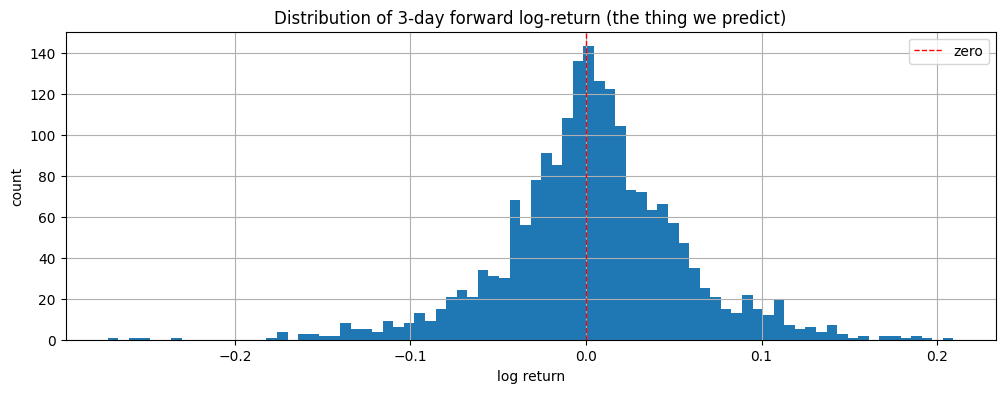

In [4]:
H = 3
df = label_regression(df, H=H)

print(f"rows: {len(df)}    H = {H} days ahead")
print(f"y_logret  mean={df['y_logret'].mean():+.4f}  std={df['y_logret'].std():.4f}  "
      f"min={df['y_logret'].min():+.3f}  max={df['y_logret'].max():+.3f}")

df["y_logret"].hist(bins=80)
plt.title(f"Distribution of {H}-day forward log-return (the thing we predict)")
plt.xlabel("log return")
plt.ylabel("count")
plt.axvline(0, color="red", linestyle="--", linewidth=1, label="zero")
plt.legend()
plt.show()


## 2.4 — Feature list

`feature_columns()` picks every numeric column except identifiers and
labels. Print the count and the names so we know what's about to be fed to
the model.

About 40 features total: the original technical indicators + the engineered
returns/vol/regime/calendar features.


In [5]:
FEATS = feature_columns(df)
print(f"{len(FEATS)} features used by the model:")
print(FEATS)


62 features used by the model:
['open', 'high', 'low', 'close', 'volume', 'ad_line', 'adx', 'atr', 'bollinger_lower', 'bollinger_middle', 'bollinger_upper', 'cci', 'ema', 'ichimoku_chikou_span', 'ichimoku_kijun', 'ichimoku_senkou_a', 'ichimoku_senkou_b', 'ichimoku_tenkan', 'keltner_lower', 'keltner_middle', 'keltner_upper', 'macd_histogram', 'macd_macd', 'macd_signal', 'momentum', 'obv', 'rsi', 'sma', 'stochastic_d', 'stochastic_k', 'volume_oscillator', 'vwap', 'williams_r', 'hash_rate', 'difficulty', 'block_time', 'miner_reserves', 'miner_outflows', 'mpi', 'exchange_inflow', 'exchange_outflow', 'exchange_reserves', 'events_in_window', 'high_impact_events_in_window', 'logret_1', 'logret_3', 'logret_5', 'logret_10', 'logret_20', 'vol_5', 'vol_20', 'vol_60', 'atr_pct', 'bb_width', 'kelt_width', 'px_vs_sma', 'sma_vs_ema', 'vol_z_20', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']
